In [1]:
import sys
import os
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

# Add project root to path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)


Circuit with initial state on q0:


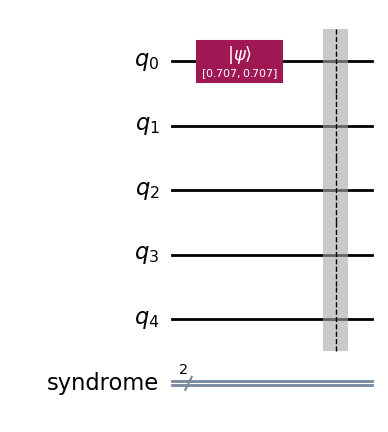

In [2]:
# Let's start with the |+> state: 1/sqrt(2) * (|0> + |1>)
psi = Statevector.from_label('+')

q = QuantumRegister(5, name='q')
syn = ClassicalRegister(2, name='syndrome')
qc = QuantumCircuit(q, syn)

qc.initialize(psi, 0)
qc.barrier()
print("Circuit with initial state on q0:")
qc.draw('mpl')


Circuit after encoding:


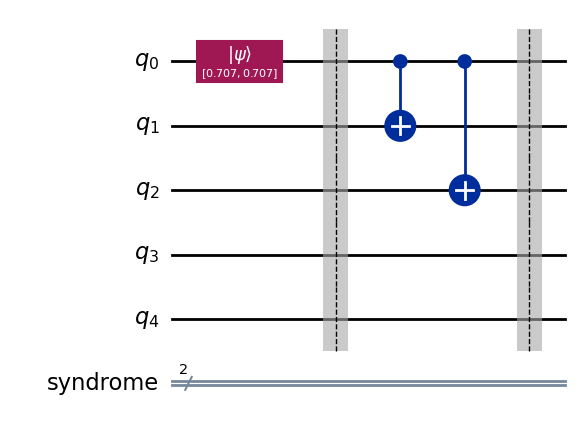

In [3]:
# Encode q0 onto q1 and q2
qc.cx(0, 1)
qc.cx(0, 2)
qc.barrier()
print("\nCircuit after encoding:")
qc.draw('mpl')


Circuit after applying an X-error to q1:


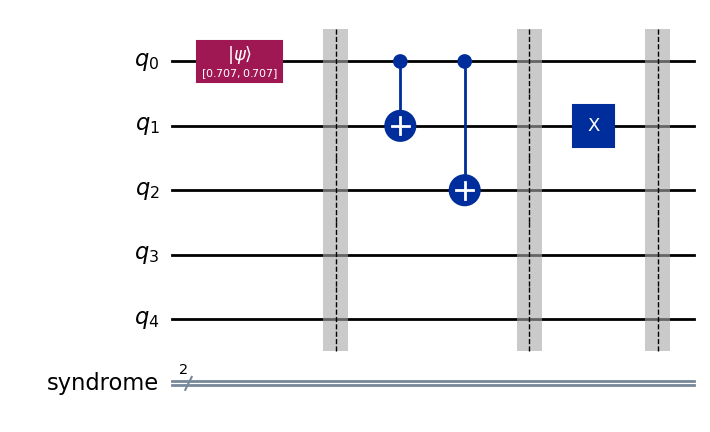

In [4]:
# Let's manually apply a bit-flip error to qubit 1
ERROR_QUBIT = 1
qc.x(ERROR_QUBIT)
qc.barrier()
print(f"\nCircuit after applying an X-error to q{ERROR_QUBIT}:")
qc.draw('mpl')


Circuit with syndrome measurement:


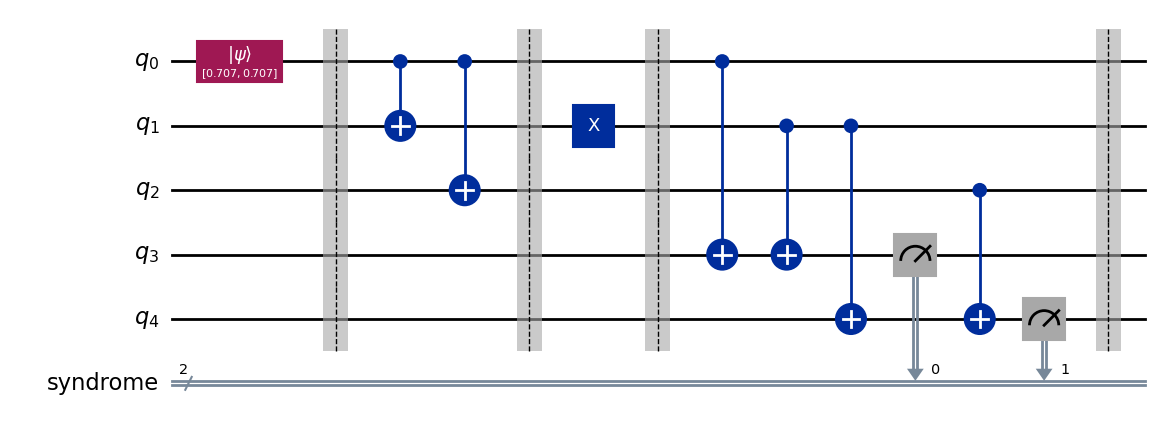

In [5]:
# Use ancilla qubits q3 and q4 to measure the error syndrome
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.measure(q[3], syn[0])
qc.measure(q[4], syn[1])
qc.barrier()
print("\nCircuit with syndrome measurement:")
qc.draw('mpl')


Full circuit with correction logic:


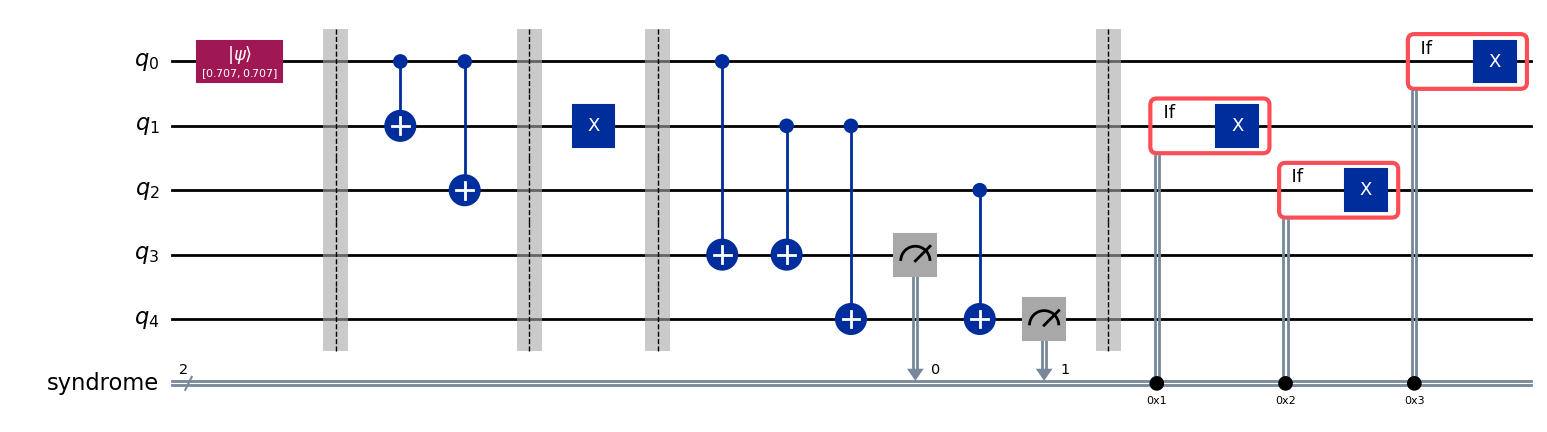

In [6]:
# Apply a correction based on the classical syndrome bits
# Syndrome '01' (decimal 1) means error on q1
with qc.if_test((syn, 1)):
    qc.x(1)
# Syndrome '10' (decimal 2) means error on q2
with qc.if_test((syn, 2)):
    qc.x(2)
# Syndrome '11' (decimal 3) means error on q0
with qc.if_test((syn, 3)):
    qc.x(0)
print("\nFull circuit with correction logic:")
qc.draw('mpl')

In [7]:
# To check the final state, we must first "un-encode" the logical qubit
qc.cx(0, 2)
qc.cx(0, 1)

# Now, let's check the final state of the logical qubit (q0)
backend = AerSimulator()
qc_state = qc.copy()
qc_state.save_statevector()
result = backend.run(qc_state).result()
final_vector = result.get_statevector()

# Extract the state of q0
final_logical_state = Statevector([final_vector.data[0], final_vector.data[1]])

print("\n--- Verification ---")
print(f"Initial State |ψ>: {np.round(psi.data, 3)}")
print(f"Final State:       {np.round(final_logical_state.data, 3)}")
print(f"States are equivalent: {psi.equiv(final_logical_state)}")


--- Verification ---
Initial State |ψ>: [0.707+0.j 0.707+0.j]
Final State:       [0.+0.j 0.+0.j]
States are equivalent: False
